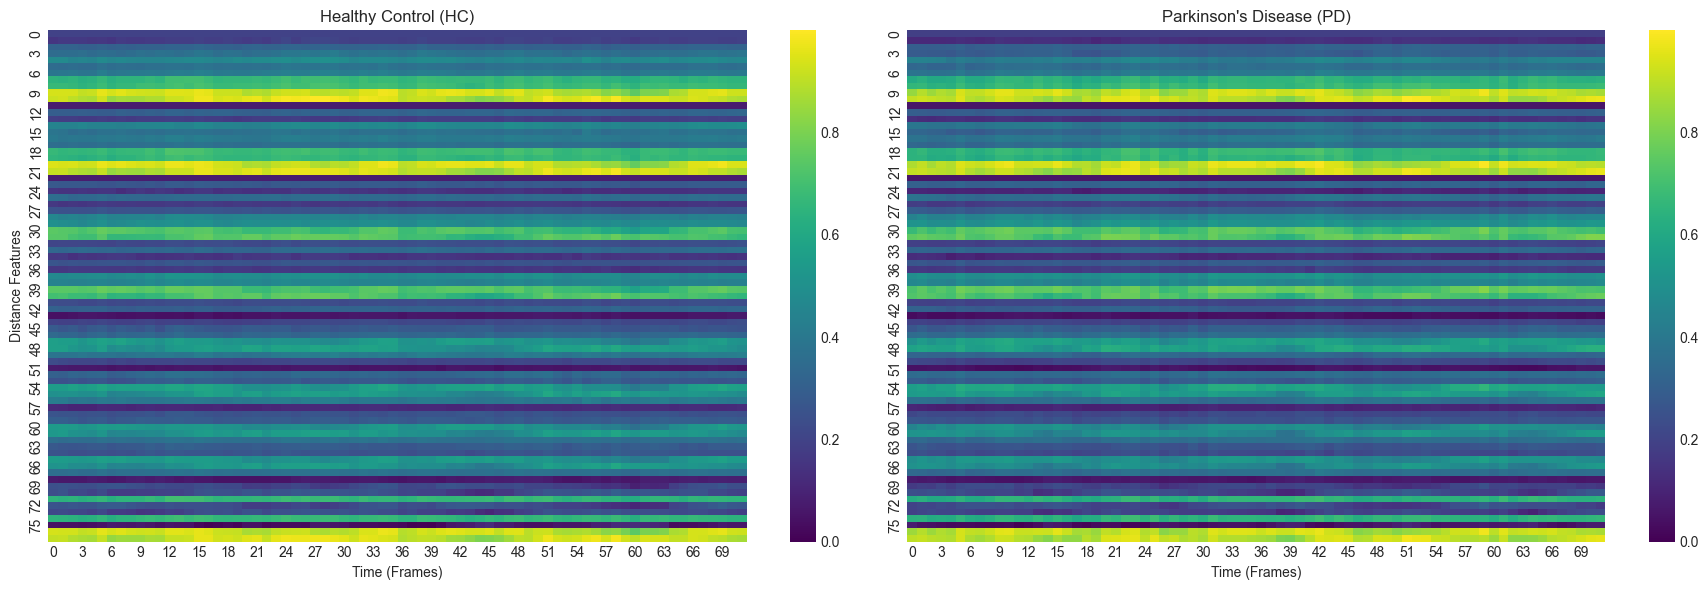

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# -----------------------------
# FILE PATHS
# -----------------------------
HC_PATH = r"datasets/Poinst_Dataset_Clips/HC/gsm/natural/forward/gsm_f1/Clip_0.npy"
# PD_PATH = r"datasets/Poinst_Dataset_Clips/PD/subject001/natural/forward/subject001/Clip_0.npy"
PD_PATH = r"datasets\Poinst_Dataset_Clips\PD\Unknown_2\natural\forward\Unknown_2_f1\Clip_0.npy"


# -----------------------------
# CONFIG
# -----------------------------
HEAD_JOINTS = [0, 1, 2, 3, 4]
LEFT_SHOULDER = 5
RIGHT_SHOULDER = 6
APPLY_MINMAX_FOR_VIS = True


# -----------------------------
# FUNCTION: PROCESS ONE SAMPLE
# -----------------------------
def process_file(file_path):
    data = np.load(file_path)  # (T,17,C)
    T, J, C = data.shape

    # Remove head
    keep_indices = [i for i in range(J) if i not in HEAD_JOINTS]
    data = data[:, keep_indices, :]

    # Update indices
    LEFT = keep_indices.index(LEFT_SHOULDER)
    RIGHT = keep_indices.index(RIGHT_SHOULDER)

    # Add midpoint
    midpoint = (data[:, LEFT, :] + data[:, RIGHT, :]) / 2
    midpoint = midpoint[:, np.newaxis, :]
    data = np.concatenate([data, midpoint], axis=1)

    T, J, C = data.shape
    TORSO = J - 1

    # Centering
    center = data[:, TORSO, :][:, np.newaxis, :]
    data_centered = data - center

    # Scale normalization
    shoulder_dist = np.linalg.norm(
        data[:, LEFT, :] - data[:, RIGHT, :], axis=1
    )
    shoulder_dist = shoulder_dist[:, np.newaxis, np.newaxis] + 1e-8

    data_norm = data_centered / shoulder_dist

    # Pairwise distances
    pairs = list(combinations(range(J), 2))
    num_features = len(pairs)

    dist_matrix = np.zeros((T, num_features))

    for t in range(T):
        joints = data_norm[t]
        for k, (i, j) in enumerate(pairs):
            dist_matrix[t, k] = np.linalg.norm(joints[i] - joints[j])

    return dist_matrix


# -----------------------------
# PROCESS BOTH
# -----------------------------
hc_matrix = process_file(HC_PATH)
pd_matrix = process_file(PD_PATH)

# -----------------------------
# OPTIONAL: MIN-MAX NORMALIZATION (FOR VIS ONLY)
# -----------------------------
if APPLY_MINMAX_FOR_VIS:
    def minmax(x):
        return (x - x.min()) / (x.max() - x.min() + 1e-8)
    
    hc_matrix = minmax(hc_matrix)
    pd_matrix = minmax(pd_matrix)

# -----------------------------
# 🔥 IMPORTANT: SAME COLOR SCALE
# -----------------------------
vmin = min(hc_matrix.min(), pd_matrix.min())
vmax = max(hc_matrix.max(), pd_matrix.max())

# -----------------------------
# PLOT SIDE-BY-SIDE
# -----------------------------
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
sns.heatmap(hc_matrix.T, cmap="viridis", vmin=vmin, vmax=vmax, cbar=True)
plt.title("Healthy Control (HC)")
plt.xlabel("Time (Frames)")
plt.ylabel("Distance Features")

plt.subplot(1, 2, 2)
sns.heatmap(pd_matrix.T, cmap="viridis", vmin=vmin, vmax=vmax, cbar=True)
plt.title("Parkinson's Disease (PD)")
plt.xlabel("Time (Frames)")
plt.ylabel("")

plt.tight_layout()
plt.show()

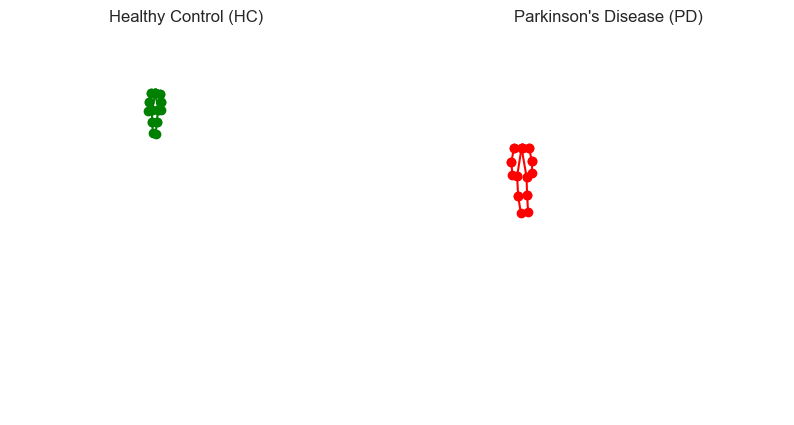

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Paths
# HC_PATH = r"datasets/Poinst_Dataset_Clips/HC/gsm/natural/forward/gsm_f1/Clip_0.npy"
# PD_PATH = r"datasets/Poinst_Dataset_Clips/PD/subject001/natural/forward/subject001/Clip_0.npy"
HC_PATH = r"datasets\Poinst_Dataset\HC\gsm\natural\forward\gsm_f1\result.npy"
PD_PATH = r"datasets\Poinst_Dataset\PD\subject001\natural\forward\subject001\result.npy"

# Load data
hc_data = np.load(HC_PATH)
pd_data = np.load(PD_PATH)

# Ensure same number of frames (take min)
frames = min(hc_data.shape[0], pd_data.shape[0])

# Skeleton connections
skeleton_connections = [
    (6, 8), (8, 10),   # Left Arm
    (5, 7), (7, 9),    # Right Arm
    (12, 14), (14, 16),# Left Leg
    (11, 13), (13, 15),# Right Leg
    (6, 17), (5, 17),  # Shoulders to center
    (12, 17), (17, 11) # Hips to center
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))


ax1.set_title("Healthy Control (HC)")
ax2.set_title("Parkinson's Disease (PD)")

for ax in [ax1, ax2]:
    ax.set_xlim(0, 1000)
    ax.set_ylim(0, 1000)
    ax.invert_yaxis()
    ax.axis("off")

hc_lines = [ax1.plot([], [], 'go-')[0] for _ in skeleton_connections]
pd_lines = [ax2.plot([], [], 'ro-')[0] for _ in skeleton_connections]

def get_extended_joints(curr):
    joint17 = (curr[5] + curr[6]) / 2
    return np.vstack([curr, joint17])

def update(frame):
    hc_curr = get_extended_joints(hc_data[frame])
    pd_curr = get_extended_joints(pd_data[frame])

    for i, (j1, j2) in enumerate(skeleton_connections):
        hc_lines[i].set_data(
            [hc_curr[j1, 0], hc_curr[j2, 0]],
            [hc_curr[j1, 1], hc_curr[j2, 1]]
        )

    for i, (j1, j2) in enumerate(skeleton_connections):
        pd_lines[i].set_data(
            [pd_curr[j1, 0], pd_curr[j2, 0]],
            [pd_curr[j1, 1], pd_curr[j2, 1]]
        )

    return hc_lines + pd_lines

# Animate

# hc_matrix = process_file(HC_PATH)
# pd_matrix = process_file(PD_PATH)

ani = FuncAnimation(fig, update, frames=frames, interval=40)

HTML(ani.to_jshtml())

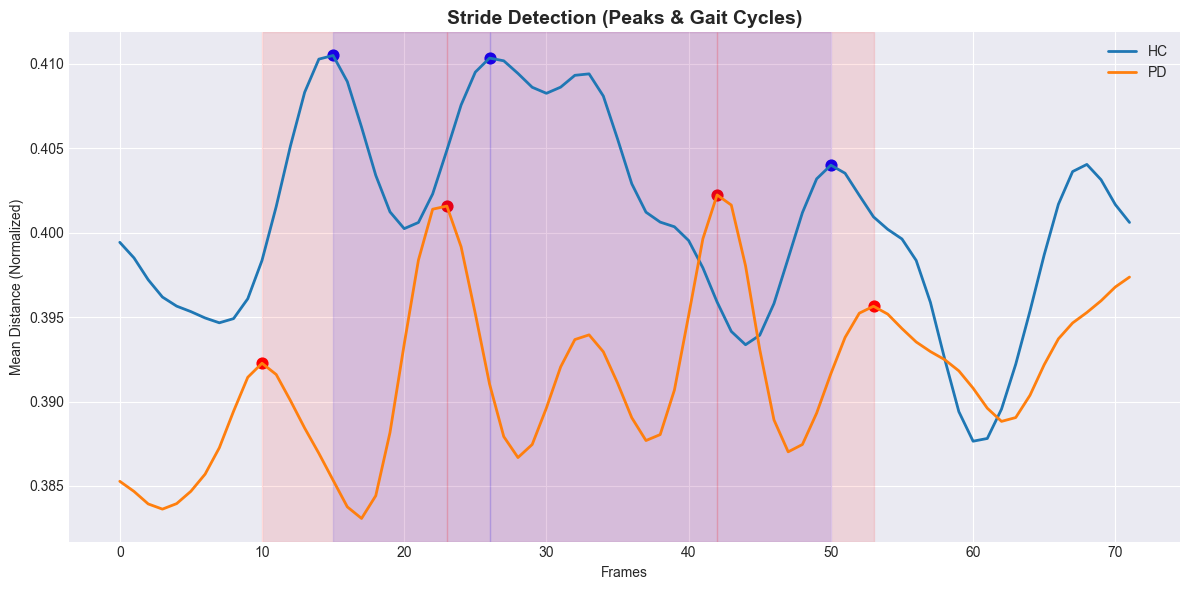

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

# -----------------------------
# SMOOTHING
# -----------------------------
def smooth(signal, sigma=2):
    return gaussian_filter1d(signal, sigma=sigma)

# -----------------------------
# GET SIGNALS
# -----------------------------
mean_hc = hc_matrix.mean(axis=1)
mean_pd = pd_matrix.mean(axis=1)

mean_hc_s = smooth(mean_hc)
mean_pd_s = smooth(mean_pd)

frames = np.arange(len(mean_hc_s))

# -----------------------------
# PEAK DETECTION (STRIDES)
# -----------------------------
peaks_hc, _ = find_peaks(mean_hc_s, distance=10, prominence=0.005)
peaks_pd, _ = find_peaks(mean_pd_s, distance=10, prominence=0.005)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(12, 6))

# HC plot
plt.plot(frames, mean_hc_s, label="HC", linewidth=2)
plt.scatter(peaks_hc, mean_hc_s[peaks_hc], color='blue', s=60)

# PD plot
plt.plot(frames, mean_pd_s, label="PD", linewidth=2)
plt.scatter(peaks_pd, mean_pd_s[peaks_pd], color='red', s=60)

# -----------------------------
# DRAW STRIDE INTERVALS
# -----------------------------
def draw_strides(peaks, signal, color):
    for i in range(len(peaks)-1):
        x1, x2 = peaks[i], peaks[i+1]
        plt.axvspan(x1, x2, alpha=0.1, color=color)

draw_strides(peaks_hc, mean_hc_s, 'blue')
draw_strides(peaks_pd, mean_pd_s, 'red')

# -----------------------------
# FINAL TOUCHES
# -----------------------------
plt.title("Stride Detection (Peaks & Gait Cycles)", fontsize=14, weight='bold')
plt.xlabel("Frames")
plt.ylabel("Mean Distance (Normalized)")
plt.legend()

plt.tight_layout()
plt.show()

In [101]:
from matplotlib.animation import PillowWriter

# Save as GIF
ani.save("gait_comparison.gif", writer=PillowWriter(fps=25))

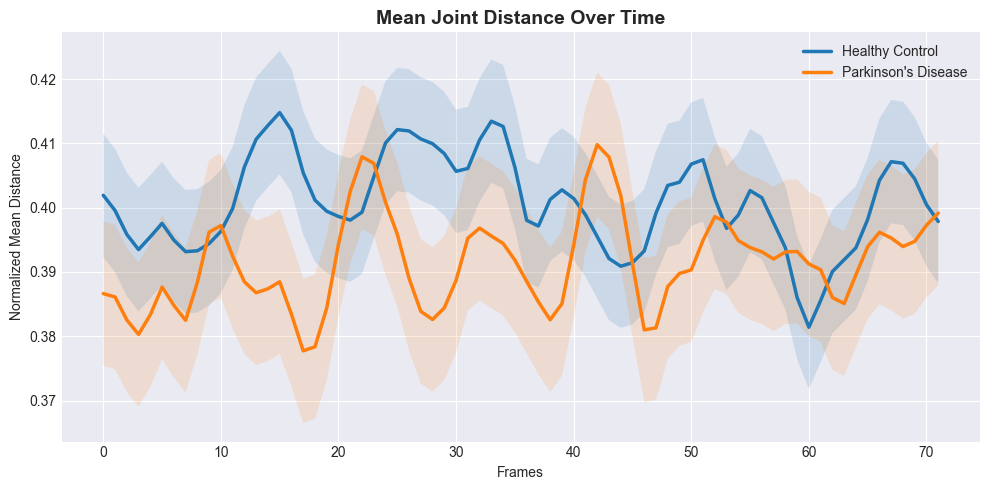

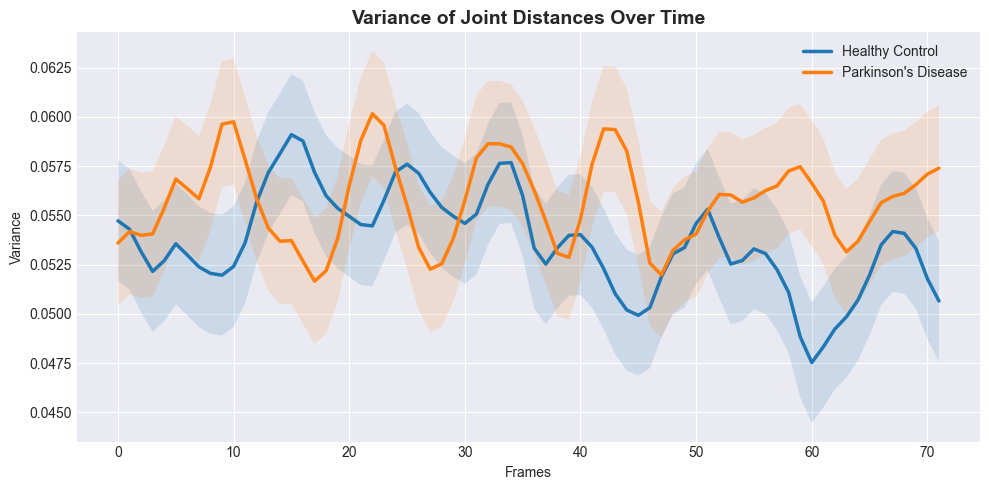

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# -----------------------------
# SMOOTHING FUNCTION
# -----------------------------
def smooth_signal(signal, sigma=1):
    return gaussian_filter1d(signal, sigma=sigma)

# -----------------------------
# COMPUTE SIGNALS
# -----------------------------
mean_hc = hc_matrix.mean(axis=1)
mean_pd = pd_matrix.mean(axis=1)

var_hc = hc_matrix.var(axis=1)
var_pd = pd_matrix.var(axis=1)

# Smooth signals
mean_hc_s = smooth_signal(mean_hc)
mean_pd_s = smooth_signal(mean_pd)

var_hc_s = smooth_signal(var_hc)
var_pd_s = smooth_signal(var_pd)

frames = np.arange(len(mean_hc))

# -----------------------------
# PLOT STYLE
# -----------------------------
plt.style.use("seaborn-v0_8-darkgrid")

# -----------------------------
# PLOT 1: MEAN DISTANCE
# -----------------------------
plt.figure(figsize=(10, 5))

plt.plot(frames, mean_hc_s, label="Healthy Control", linewidth=2.5)
plt.plot(frames, mean_pd_s, label="Parkinson's Disease", linewidth=2.5)

# Confidence bands
plt.fill_between(frames, mean_hc_s - np.std(mean_hc), mean_hc_s + np.std(mean_hc), alpha=0.15)
plt.fill_between(frames, mean_pd_s - np.std(mean_pd), mean_pd_s + np.std(mean_pd), alpha=0.15)

plt.title("Mean Joint Distance Over Time", fontsize=14, weight='bold')
plt.xlabel("Frames")
plt.ylabel("Normalized Mean Distance")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# PLOT 2: VARIANCE
# -----------------------------
plt.figure(figsize=(10, 5))

plt.plot(frames, var_hc_s, label="Healthy Control", linewidth=2.5)
plt.plot(frames, var_pd_s, label="Parkinson's Disease", linewidth=2.5)

plt.fill_between(frames, var_hc_s - np.std(var_hc), var_hc_s + np.std(var_hc), alpha=0.15)
plt.fill_between(frames, var_pd_s - np.std(var_pd), var_pd_s + np.std(var_pd), alpha=0.15)

plt.title("Variance of Joint Distances Over Time", fontsize=14, weight='bold')
plt.xlabel("Frames")
plt.ylabel("Variance")
plt.legend()
plt.tight_layout()
plt.show()

HC Symmetry Index: 0.059416287
PD Symmetry Index: 0.06582874


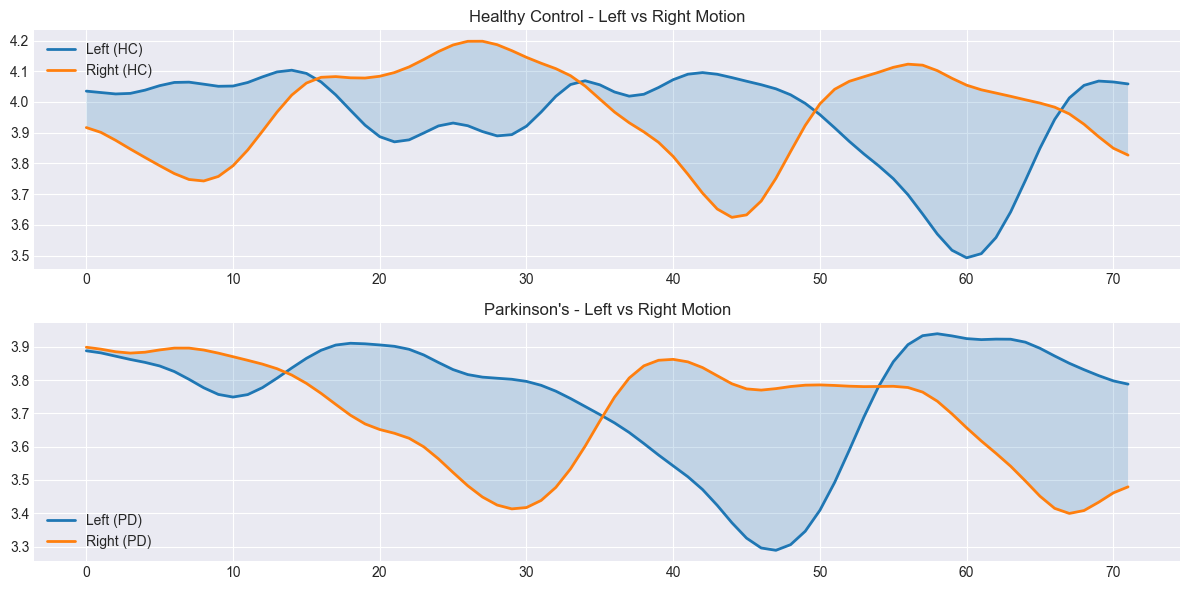

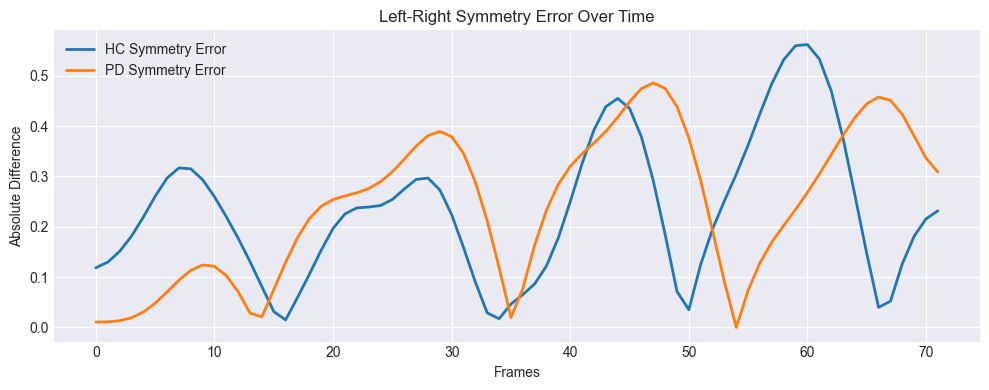

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# -----------------------------
# CONFIG (COCO FORMAT)
# -----------------------------
LEFT_ANKLE = 15
RIGHT_ANKLE = 16
LEFT_KNEE = 13
RIGHT_KNEE = 14
LEFT_SHOULDER = 5
RIGHT_SHOULDER = 6

HEAD_JOINTS = [0,1,2,3,4]

# -----------------------------
# LOAD + PREPROCESS FUNCTION
# -----------------------------
def load_and_preprocess(file_path):
    data = np.load(file_path)  # (T,17,C)

    # Remove head
    keep = [i for i in range(data.shape[1]) if i not in HEAD_JOINTS]
    data = data[:, keep, :]

    # Update indices
    def new_idx(old):
        return keep.index(old)

    L_ANK = new_idx(LEFT_ANKLE)
    R_ANK = new_idx(RIGHT_ANKLE)
    L_SH = new_idx(LEFT_SHOULDER)
    R_SH = new_idx(RIGHT_SHOULDER)

    # Midpoint (torso)
    torso = (data[:, L_SH, :] + data[:, R_SH, :]) / 2
    torso = torso[:, np.newaxis, :]
    data = np.concatenate([data, torso], axis=1)

    TORSO = data.shape[1] - 1

    # Centering
    center = data[:, TORSO, :][:, np.newaxis, :]
    data_centered = data - center

    # Scale normalization
    scale = np.linalg.norm(data[:, L_SH, :] - data[:, R_SH, :], axis=1)
    scale = scale[:, np.newaxis, np.newaxis] + 1e-8
    data_norm = data_centered / scale

    return data_norm, L_ANK, R_ANK


# -----------------------------
# SYMMETRY FUNCTION
# -----------------------------
def compute_symmetry(data, L_idx, R_idx):
    # distance from torso (already centered → just magnitude)
    left = np.linalg.norm(data[:, L_idx, :], axis=1)
    right = np.linalg.norm(data[:, R_idx, :], axis=1)

    return left, right


# -----------------------------
# SMOOTHING
# -----------------------------
def smooth(x):
    return gaussian_filter1d(x, sigma=2)


# -----------------------------
# LOAD DATA
# -----------------------------
hc_data, hc_L, hc_R = load_and_preprocess(HC_PATH)
pd_data, pd_L, pd_R = load_and_preprocess(PD_PATH)

# -----------------------------
# COMPUTE SIGNALS
# -----------------------------
hc_left, hc_right = compute_symmetry(hc_data, hc_L, hc_R)
pd_left, pd_right = compute_symmetry(pd_data, pd_L, pd_R)

# Smooth
hc_left_s = smooth(hc_left)
hc_right_s = smooth(hc_right)

pd_left_s = smooth(pd_left)
pd_right_s = smooth(pd_right)

frames = np.arange(len(hc_left_s))

# -----------------------------
# SYMMETRY SIGNAL (difference)
# -----------------------------
hc_diff = np.abs(hc_left_s - hc_right_s)
pd_diff = np.abs(pd_left_s - pd_right_s)

# -----------------------------
# SYMMETRY INDEX (SCALAR)
# -----------------------------
def symmetry_index(left, right):
    return np.mean(np.abs(left - right) / (0.5*(left + right) + 1e-8))

print("HC Symmetry Index:", symmetry_index(hc_left_s, hc_right_s))
print("PD Symmetry Index:", symmetry_index(pd_left_s, pd_right_s))


# -----------------------------
# PLOTTING
# -----------------------------
plt.figure(figsize=(12,6))

# --- HC ---
plt.subplot(2,1,1)
plt.plot(frames, hc_left_s, label="Left (HC)", linewidth=2)
plt.plot(frames, hc_right_s, label="Right (HC)", linewidth=2)
plt.fill_between(frames, hc_left_s, hc_right_s, alpha=0.2)
plt.title("Healthy Control - Left vs Right Motion")
plt.legend()

# --- PD ---
plt.subplot(2,1,2)
plt.plot(frames, pd_left_s, label="Left (PD)", linewidth=2)
plt.plot(frames, pd_right_s, label="Right (PD)", linewidth=2)
plt.fill_between(frames, pd_left_s, pd_right_s, alpha=0.2)
plt.title("Parkinson's - Left vs Right Motion")
plt.legend()

plt.tight_layout()
plt.show()


# -----------------------------
# DIFFERENCE PLOT (IMPORTANT)
# -----------------------------
plt.figure(figsize=(10,4))

plt.plot(frames, hc_diff, label="HC Symmetry Error", linewidth=2)
plt.plot(frames, pd_diff, label="PD Symmetry Error", linewidth=2)

plt.title("Left-Right Symmetry Error Over Time")
plt.xlabel("Frames")
plt.ylabel("Absolute Difference")
plt.legend()

plt.tight_layout()
plt.show()

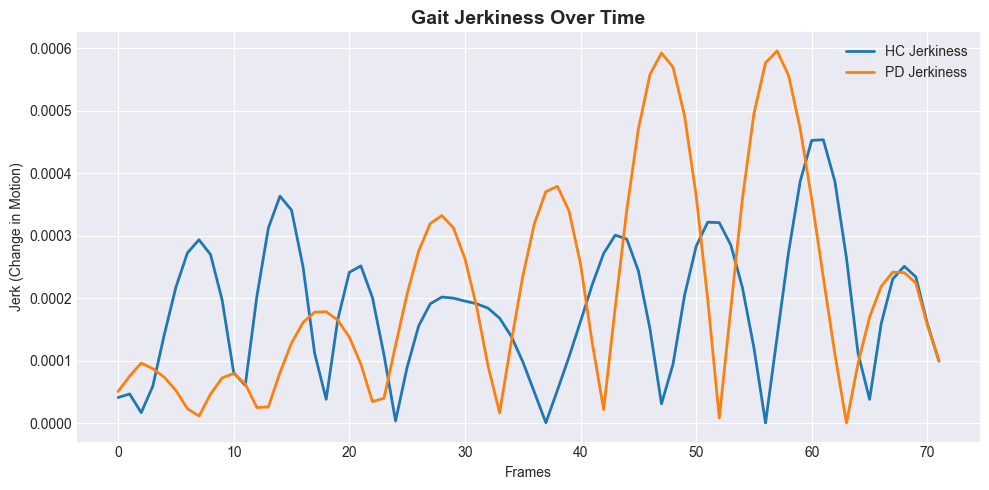

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# -----------------------------
# FUNCTION: COMPUTE JERKINESS
# -----------------------------
def compute_jerk(signal):
    # Smooth first (important)
    signal_s = gaussian_filter1d(signal, sigma=4)    
    # First derivative
    vel = np.gradient(signal_s)
    
    # Second derivative (jerk proxy)
    jerk = np.gradient(vel)
    
    return np.abs(jerk)

# -----------------------------
# COMPUTE JERK
# -----------------------------
hc_jerk = compute_jerk(mean_hc)
pd_jerk = compute_jerk(mean_pd)

frames = np.arange(len(hc_jerk))

# -----------------------------
# PLOT JERKINESS
# -----------------------------
plt.figure(figsize=(10,5))

plt.plot(frames, hc_jerk, label="HC Jerkiness", linewidth=2)
plt.plot(frames, pd_jerk, label="PD Jerkiness", linewidth=2)

plt.title("Gait Jerkiness Over Time", fontsize=14, weight='bold')
plt.xlabel("Frames")
plt.ylabel("Jerk (Change in Motion)")
plt.legend()

plt.tight_layout()
plt.show()